# Course 3 — Anomaly Detection
==============================

Anomaly detection is an unsupervised learning technique used to identify rare items, events, or observations that raise suspicion by differing significantly from the majority of the data.

### In this notebook, we will explore:
1. **Gaussian Density Estimation**: Modeling normal data behavior using a product of Gaussian distributions.
2. **Threshold Selection ($\epsilon$)**: Tuning the detection threshold using the F1-score on a validation (dev) set.
3. **Visualization**: Plotting the density contours and showing how outliers are separated from normal points.

In [1]:
import sys
from pathlib import Path
# Add repository root to sys.path dynamically
project_root = Path(".").resolve()
while project_root.name and not (project_root / "utils").is_dir():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score


## 1. Data Generation & Strategic Splitting

We generate a synthetic normal cluster and add randomly distributed outliers. Unlike standard supervised learning, the splits are allocated as:
- **Training Set**: $100\%$ normal examples to learn the "normal" data density.
- **Dev (Validation) Set**: Contains a few anomalies and normal examples to choose the optimal classification threshold $\epsilon$.
- **Test Set**: Contains anomalies and normal examples to measure final generalization performance.

In [2]:
rng = np.random.default_rng(42)
X_normal = rng.multivariate_normal([3, 3], [[1, 0.5], [0.5, 1]], size=200)
X_anomalies = rng.uniform(low=-2, high=8, size=(20, 2))

# Split: train on 160 normal data; dev & test get 20 normal + 10 anomalies each
X_train = X_normal[:160]
X_dev = np.vstack([X_normal[160:180], X_anomalies[:10]])
y_dev = np.array([0] * 20 + [1] * 10)

X_test = np.vstack([X_normal[180:200], X_anomalies[10:]])
y_test = np.array([0] * 20 + [1] * 10)

## 2. Gaussian Density Estimation

For an input sample $\mathbf{x} \in \mathbb{R}^n$, we assume the features are independent and model the probability density $p(\mathbf{x})$ as the product of $n$ univariate Gaussian distributions:
$$p(\mathbf{x}) = \prod_{j=1}^n p(x_j; \mu_j, \sigma_j^2) = \prod_{j=1}^n \frac{1}{\sqrt{2\pi}\sigma_j} \exp\left(-\frac{(x_j - \mu_j)^2}{2\sigma_j^2}\right)$$

We estimate the mean $\mu_j$ and variance $\sigma_j^2$ of each feature $j$ using the training set:
$$\mu_j = \frac{1}{m} \sum_{i=1}^m x_j^{(i)}, \quad \sigma_j^2 = \frac{1}{m} \sum_{i=1}^m (x_j^{(i)} - \mu_j)^2$$

In [3]:
# ── Gaussian Density Estimation ───────────────────────────────────────

def estimate_gaussian(X):
    """Estimate mean and variance for each feature."""
    mu = np.mean(X, axis=0)
    var = np.var(X, axis=0)
    return mu, var


def gaussian_pdf(X, mu, var):
    """Compute P(X | mu, var) for each example."""
    eps = 1e-8
    numerator = np.exp(-((X - mu) ** 2) / (2 * var + eps))
    denominator = np.sqrt(2 * np.pi * var + eps)
    return np.prod(numerator / denominator, axis=1)

In [4]:
mu, var = estimate_gaussian(X_train)
print(f"Feature means:     {mu}")
print(f"Feature variances: {var}")

Feature means:     [3.00761332 2.94091028]
Feature variances: [0.95176768 0.85889377]


## 3. Threshold Selection ($\epsilon$)

We classify a point $\mathbf{x}$ as an anomaly if its calculated probability is below a threshold:
$$y_{\text{pred}} = \begin{cases} 1 & \text{if } p(\mathbf{x}) < \epsilon \\ 0 & \text{if } p(\mathbf{x}) \ge \epsilon \end{cases}$$

We perform a grid search on the dev set to select the $\epsilon$ that maximizes the **F1-score**, which balances precision and recall on our highly imbalanced validation samples.

In [5]:
# ── Threshold Selection ───────────────────────────────────────────────

print("\n── Selecting ε (threshold) on Dev Set ──")

p_dev = gaussian_pdf(X_dev, mu, var)
p_test = gaussian_pdf(X_test, mu, var)

# Try many thresholds, pick best by F1
best_eps = 0
best_f1 = 0
step_size = (p_dev.max() - p_dev.min()) / 1000

for eps in np.arange(p_dev.min(), p_dev.max(), step_size):
    y_pred = (p_dev < eps).astype(int)
    f1 = f1_score(y_dev, y_pred, zero_division=0)
    if f1 > best_f1:
        best_f1 = f1
        best_eps = eps

print(f"Best ε:  {best_eps:.6f}")
print(f"Best F1: {best_f1:.4f}")


── Selecting ε (threshold) on Dev Set ──
Best ε:  0.000496
Best F1: 1.0000


## 4. Evaluation & Contours Visualization

Evaluate our selected threshold on the test set and plot the density contours alongside the points to visualize the boundary.

In [6]:
# ── Evaluate on Test Set ──────────────────────────────────────────────

y_test_pred = (p_test < best_eps).astype(int)
test_f1 = f1_score(y_test, y_test_pred, zero_division=0)
print(f"Test F1: {test_f1:.4f}")

Test F1: 0.8889


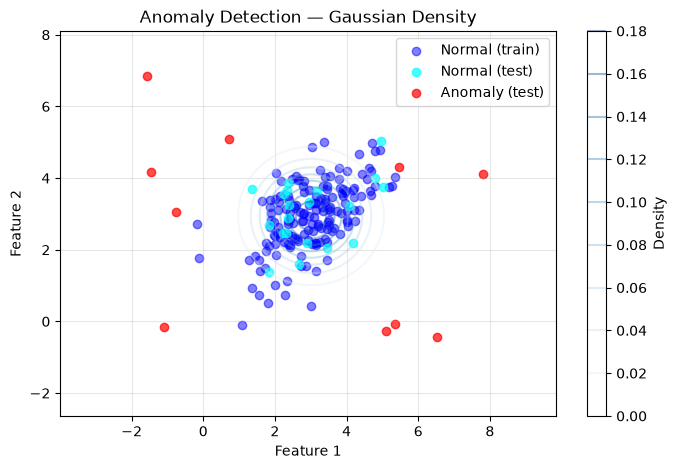

In [7]:
# Visualise
X_all = np.vstack([X_normal, X_anomalies])
plt.figure(figsize=(8, 5))
plt.scatter(X_train[:, 0], X_train[:, 1], c="blue", alpha=0.5, label="Normal (train)")
plt.scatter(X_test[y_test == 0, 0], X_test[y_test == 0, 1],
            c="cyan", alpha=0.7, label="Normal (test)")
plt.scatter(X_test[y_test == 1, 0], X_test[y_test == 1, 1],
            c="red", alpha=0.7, label="Anomaly (test)")

# Contour of Gaussian
x_min, x_max = X_all[:, 0].min() - 1, X_all[:, 0].max() + 1
y_min, y_max = X_all[:, 1].min() - 1, X_all[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))
Z = gaussian_pdf(np.c_[xx.ravel(), yy.ravel()], mu, var)
Z = Z.reshape(xx.shape)
plt.contour(xx, yy, Z, levels=10, cmap="Blues", alpha=0.4)
plt.colorbar(label="Density")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Anomaly Detection — Gaussian Density")
plt.legend()
plt.axis("equal")
plt.grid(alpha=0.3)
plt.show()

## Key Takeaways

- **Gaussian density estimation**: Models the joint probability distribution of the features as $P(x) = \prod_{j=1}^n P(x_j; \mu_j, \sigma_j^2)$.
- **Anomaly condition**: Anomaly is flagged when the density probability $P(x) < \epsilon$.
- **Threshold selection**: Since anomalies are rare, use F1 score on the validation (dev) set to select the optimal threshold $\epsilon$.
- **Data representation assumption**: Assumes normal features are Gaussian. If a feature is highly skewed, apply a transformation (like $\log(x)$ or $x^{0.5}$) to normalize it before modeling.
- **Supervised vs Anomaly detection**:
  - **Anomaly Detection**: Very few positive examples (anomalies). New anomalies may look completely different from past ones.
  - **Supervised Learning**: Large balance of both positive and negative examples; future positive samples are expected to resemble training samples.

In [8]:
# ── Key Takeaways ─────────────────────────────────────────────────────
print("""
╔══ Key Takeaways ───────────────────────────────────────────────╗
║ • Model P(x) = Π P(xⱼ | μⱼ, σⱼ²) for each feature j          ║
║ • Anomaly if P(x) < ε (very low probability)                  ║
║ • Choose ε on dev set using F1 score                          ║
║ • Assumes features are Gaussian → can transform if needed     ║
║ • Works well when anomalies are rare (e.g. < 5% of data)      ║
║ • Compared to supervised:                                     ║
║   - Anomaly detection: very few positive examples, many types  ║
║   - Supervised: enough positive/negative examples              ║
╚════════════════════════════════════════════════════════════════╝
""")


╔══ Key Takeaways ───────────────────────────────────────────────╗
║ • Model P(x) = Π P(xⱼ | μⱼ, σⱼ²) for each feature j          ║
║ • Anomaly if P(x) < ε (very low probability)                  ║
║ • Choose ε on dev set using F1 score                          ║
║ • Assumes features are Gaussian → can transform if needed     ║
║ • Works well when anomalies are rare (e.g. < 5% of data)      ║
║ • Compared to supervised:                                     ║
║   - Anomaly detection: very few positive examples, many types  ║
║   - Supervised: enough positive/negative examples              ║
╚════════════════════════════════════════════════════════════════╝

